##   просчет роллов в артах


In [19]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import scipy.stats as stats
import pylab
import struct


%matplotlib inline

In [21]:
n_exp = 10000

n_exp = 500
n_discs = 5000
n_substats = 4

TOTAL_COUNT = 100
BATCH_SIZE = 10
#random.seed(a=2, version=2)

### Genshin

In [31]:
main_stat_values_map = {
    stats_map["hp"]: 4780, 
    stats_map["hp%"]: 46.6,
    stats_map["atk"]: 311,
    stats_map["atk%"]: 46.6,
    stats_map["def%"]: 58.3,
    stats_map["EM"]: 187,
    stats_map["ER"]: 51.8,
    stats_map["CR"]: 31.1,
    stats_map["CD"]: 62.2,
    stats_map["Fire Bonus"]: 46.6, # same for all elements
    stats_map["Physical Bonus"]: 58.3,
    stats_map["Heal Bonus"]: 35.9
}


# 100%, 90%, 80%, 70%
sub_stats_values_map = {
    stats_map["hp"]: [209.13, 239, 269.88, 299.75], 
    stats_map["hp%"]: [4.08, 4.66, 5.25, 5.83],
    stats_map["atk"]: [13.62, 15.56, 17.51, 19.45],
    stats_map["atk%"]: [4.08, 4.66, 5.25, 5.83],
    stats_map["def"]: [16.2, 18.52, 20.83, 23.15],
    stats_map["def%"]: [5.1, 5.83, 6.56, 7.29],
    stats_map["EM"]: [16.32, 18.65, 20.98, 23.31],
    stats_map["ER"]: [4.53, 5.18, 5.83, 6.48],
    stats_map["CR"]: [2.72, 3.11, 3.5, 3.89],
    stats_map["CD"]: [544, 6.22, 6.99, 7.77]
}

In [34]:
stats_map = {
    "hp": 0, 
    "hp%": 1,
    "atk": 2,
    "atk%": 3,
    "def": 4,
    "def%": 5,
    "EM": 6, # Elemental mastery
    "ER": 7, # Energy recharge
    "CR": 8, # Crit Rate
    "CD": 9, # Crit Damage
    "Physical Bonus": 10,
    "Fire Bonus": 11,
    "Hydro Bonus": 12,
    "Anemo Bonus": 13,
    "Electro Bonus": 14,
    "Dendro Bonus": 15,
    "Cryo Bonus": 16,
    "Geo Bonus": 17,
    "Heal Bonus": 18,
}

main_stat_values_map = {
    stats_map["hp"]: 478000, 
    stats_map["hp%"]: 4660,
    stats_map["atk"]: 3110,
    stats_map["atk%"]: 4660,
    stats_map["def%"]: 5830,
    stats_map["EM"]: 18700,
    stats_map["ER"]: 5180,
    stats_map["CR"]: 3110,
    stats_map["CD"]: 6220,
    stats_map["Fire Bonus"]: 4660, # same for all elements
    stats_map["Physical Bonus"]: 5830,
    stats_map["Heal Bonus"]: 3590
}


base_sub_stats_choices = [
    stats_map["hp"], 
    stats_map["hp%"],
    stats_map["atk"],
    stats_map["atk%"],
    stats_map["def"],
    stats_map["def%"],
    stats_map["EM"],
    stats_map["ER"],
    stats_map["CR"],
    stats_map["CD"]
]

# 100%, 90%, 80%, 70%
sub_stats_values_map = {
    stats_map["hp"]: [20913, 23900, 26988, 29975], 
    stats_map["hp%"]: [408, 466, 525, 583],
    stats_map["atk"]: [1362, 1556, 1751, 1945],
    stats_map["atk%"]: [408, 466, 525, 583],
    stats_map["def"]: [162, 1852, 2083, 2315],
    stats_map["def%"]: [51, 583, 656, 729],
    stats_map["EM"]: [1632, 1865, 2098, 2331],
    stats_map["ER"]: [453, 518, 583, 648],
    stats_map["CR"]: [272, 311, 35, 389],
    stats_map["CD"]: [544, 622, 699, 777]
}

sub_stats_values_count = 4

sub_stats_weights_map = {
    stats_map["hp%"]: 4,
    stats_map["hp"]: 6,
    stats_map["atk%"]: 4,
    stats_map["atk"]: 6,
    stats_map["def%"]: 4,
    stats_map["def"]: 6,
    stats_map["EM"]: 4,
    stats_map["ER"]: 4,
    stats_map["CR"]: 3,
    stats_map["CD"]: 3
}

In [14]:
slot_1_pop = [stats_map["hp"]]
slot_1_prob = [1]

slot_2_pop = [stats_map["atk"]]
slot_2_prob = [1]

slot_3_pop = [
    stats_map["hp%"],
    stats_map["atk%"],
    stats_map["def%"],
    stats_map["ER"],
    stats_map["EM"]
]
slot_3_prob = [0.8/3, 0.8/3, 0.8/3, 0.1, 0.1]

slot_4_pop = [
    stats_map["hp%"],
    stats_map["atk%"],
    stats_map["def%"],
    stats_map["Physical Bonus"],
    stats_map["Fire Bonus"],
    stats_map["Hydro Bonus"],
    stats_map["Anemo Bonus"],
    stats_map["Electro Bonus"],
    stats_map["Dendro Bonus"],
    stats_map["Cryo Bonus"],
    stats_map["Geo Bonus"],
    stats_map["EM"]
]
slot_4_prob = [0.1925, 0.1925, 0.19, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.025]

slot_5_pop = [
    stats_map["hp%"],
    stats_map["atk%"],
    stats_map["def%"],
    stats_map["CR"],
    stats_map["CD"],
    stats_map["EM"],
    stats_map["Heal Bonus"]
]
slot_5_prob = [0.22, 0.22, 0.22, 0.1, 0.1, 0.04, 0.1]

In [15]:
print(sum(slot_1_prob))
print(sum(slot_2_prob))
print(sum(slot_3_prob))
print(sum(slot_4_prob))
print(sum(slot_5_prob))

print(len(slot_1_pop) == len(slot_1_prob))
print(len(slot_2_pop) == len(slot_2_prob))
print(len(slot_3_pop) == len(slot_3_prob))
print(len(slot_4_pop) == len(slot_4_prob))
print(len(slot_5_pop) == len(slot_5_prob))

1
1
1.0
1.0000000000000002
1.0
True
True
True
True
True


In [ ]:


sub_rolls_map = {}
for item in sub_stats_map.items():
    avrg = (item[1][0] + item[1][-1]) / 2
    roll_list = []
    for value in item[1]:
        roll_list.append(round(value/avrg, 3))
    sub_rolls_map[item[0]] = roll_list 

In [ ]:
rolls_proportion_map = {
    "hp": 0, 
    "hp%": 0,
    "atk": 0.25,
    "atk%": 0.75,
    "def": 0,
    "def%": 0,
    "EM": 0.75,
    "ER": 0.5,
    "CR": 1,
    "CD": 1
}

base_stats = {     
    "hp": 0, 
    "hp%": 0,
    "atk": 0,
    "atk%": 0,
    "def": 0,
    "def%": 0,
    "EM": 0,
    "ER": 0,
    "CR": 0,
    "CD": 0,
    "ED": 0,
    "PhysD": 0,
    "HillB": 0
}
stats_sum = []
rolls_sum = []
good_rolls_sum = []

In [26]:

random.choices([1, 2, 3], k=6)

[3, 2, 1, 1, 2, 2]

In [27]:
artifact = (
                0,  # HP
                1,  # ATK
                0,  # DEF
                0,  # HP%
                0,  # ATK%
                0,  # DEF%
                0,  # Crit Rate
                0,  # Crit Damage
                0,  # Energy Recharge
                0,  # Elemental Mastery
            )
artifact[5] = 4
artifact

TypeError: 'tuple' object does not support item assignment

### генерация артефакта

In [24]:
def generate_art_for_file(choices, count_roll = 4):
    artifact = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    stat_0_level_sample = random.sample(choices, k = 4) # 4 sub stat in artifact
    stat_upgrade_choice = random.choices(stat_sample, k = count_roll) # rolls doring upgrade
    
    for stat in stat_0_level_sample:
        index = random.randint(0, sub_stats_values_count - 1)
        artifact[stat] += sub_stats_map[stat][index]
        
    for stat in stat_upgrade_choice:
        index = random.randint(0, sub_stats_values_count - 1)
        artifact[stat] += sub_stats_map[stat][index]
    
    return artifact


def generate_art_for_file(deleted_stat)
    with open("artifacts.bin", "wb") as file:
        stats = base_stats.copy()
        rolls = base_stats.copy()
        stats[deleted_stat] = main_stats_map[deleted_stat]
        possible_sub_stats = base_sub_stats_choices.copy()
        if deleted_stat in possible_sub_stats:
            possible_sub_stats.remove(deleted_stat)
        count_roll = 4

        count_3_base_stat_arts = TOTAL_COUNT * 4 / 5

        for start in range(0, count_3_base_stat_arts, BATCH_SIZE):
            current_size = min(BATCH_SIZE, TOTAL_COUNT - start)

            artifacts = []


            # Здесь потом будет генерация
            for _ in range(current_size):
                

                artifacts.append(generate_art_for_file(possible_sub_stats, 4))

            # Запись batch в файл
            data = bytearray()

            for artifact in artifacts:
                data.extend(struct.pack("<10i", *artifact))

            file.write(data)
            generated = start + current_size
            percent = generated / TOTAL_COUNT * 100

            print(
                f"\rGenerated: {generated:,} / {TOTAL_COUNT:,} "
                f"({percent:.2f}%)",
                end="",
                flush=True
            )

    print("\nGeneration completed.")

Generated: 100 / 100 (100.00%)
Generation completed.


In [25]:
with open("artifacts.bin", "rb") as file:
    data = file.read(40)

    artifact = struct.unpack("<10i", data)

    print(artifact)

(0, 1, 0, 0, 0, 0, 0, 0, 0, 0)


In [214]:
def art_func(deleted_stat):
    stats = base_stats.copy()
    rolls = base_stats.copy()
    stats[deleted_stat] = main_stats_map[deleted_stat]
    choices = base_choices.copy()
    if deleted_stat in choices:
        choices.remove(deleted_stat)
    count_roll = random.randint(4, 5)
    
    stat_sample = random.sample(choices, k=4)
    stat_choice = random.choices(stat_sample, k=count_roll)
    
    for stat in stat_sample:
        index = random.randint(0, len(sub_stats_map[stat]) - 1)
        stats[stat] += sub_stats_map[stat][index]
        rolls[stat] += sub_rolls_map[stat][index]
        
    for stat in stat_choice:
        index = random.randint(0, len(sub_stats_map[stat]) - 1)
        stats[stat] += sub_stats_map[stat][index]
        rolls[stat] += sub_rolls_map[stat][index]
    
    return [stats, rolls]

In [215]:
art_main_stats = ["hp", "atk", "atk%", "ED", "CR"]
full_stats = base_stats.copy()
full_rolls = base_stats.copy()

for main_stat in art_main_stats:
    art_stat, art_roll = art_func(main_stat)
    for item in art_stat.items():
        full_stats[item[0]] += item[1]
    for item in art_roll.items():
        full_rolls[item[0]] += item[1]

for item in full_stats.items():
        full_stats[item[0]] = round(item[1], 2)
        
for item in full_rolls.items():
        full_rolls[item[0]] = round(item[1], 2)
        
good_rolls = 0
for item in rolls_proportion_map.items():
    good_rolls += full_rolls[item[0]] * item[1]
good_rolls = round(good_rolls, 2)
print(full_stats)
print(full_rolls)
print(good_rolls)

{'hp': 6036.76, 'hp%': 34.39, 'atk': 406.33, 'atk%': 60.0, 'def': 16.2, 'def%': 24.78, 'EM': 86.25, 'ER': 20.07, 'CR': 60.27, 'CD': 0, 'ED': 46.6, 'PhysD': 0, 'HillB': 0}
{'hp': 4.94, 'hp%': 6.94, 'atk': 5.77, 'atk%': 2.7, 'def': 0.82, 'def%': 4.0, 'EM': 4.35, 'ER': 3.65, 'CR': 8.83, 'CD': 0, 'ED': 0, 'PhysD': 0, 'HillB': 0}
17.38


In [216]:
def genshin_art_func():
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        art_main_stats = ["hp", "atk", "atk%", "ED", "CR"]
        full_stats = base_stats.copy()
        full_rolls = base_stats.copy()

        for main_stat in art_main_stats:
            art_stat, art_roll = art_func(main_stat)
            for item in art_stat.items():
                full_stats[item[0]] += item[1]
            for item in art_roll.items():
                full_rolls[item[0]] += item[1]

        for item in full_stats.items():
                full_stats[item[0]] = round(item[1], 2)

        #stats_sum.append(full_stats)
        #rolls_sum.append(full_rolls)
        good_rolls = 0
        for item in rolls_proportion_map.items():
            good_rolls += full_rolls[item[0]] * item[1]

        res[i] = good_rolls

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc] 

In [217]:
q, frame, w = genshin_art_func()
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,13.234200
0.200,14.733250
0.400,16.795400
0.500,17.676875
0.550,18.148362
0.600,18.618100
0.650,19.089838
0.700,19.616000
0.750,20.175625
0.800,20.798050


In [218]:
count_good_rolls = 25

sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= count_good_rolls])/n_exp

0.9759

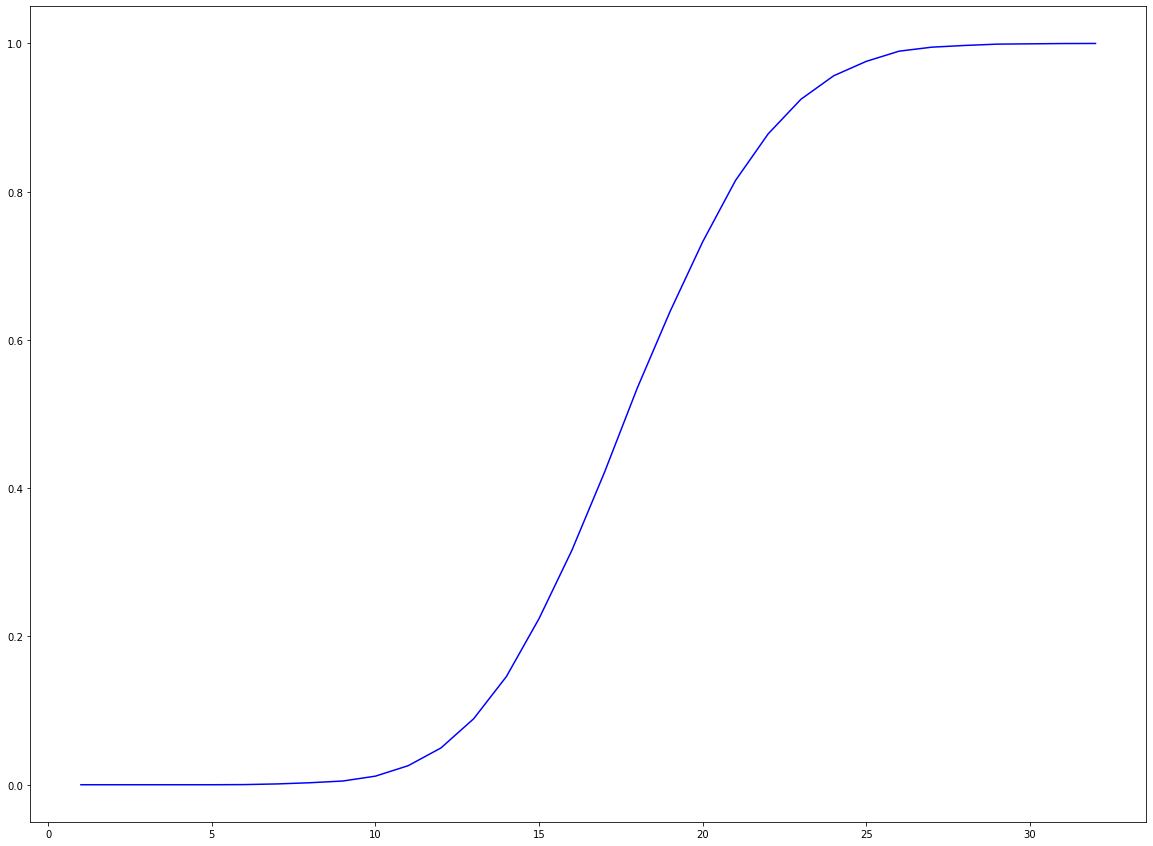

In [219]:
x=[]
y=[]
i = 1
prob = 0
while prob < 1:
    prob = len(sorted[sorted[0] <= i])/n_exp
    x.append(i)
    y.append(prob)
    i+=1
    

plt.figure(figsize=(20, 15))
plt.plot(x, y, color ='blue')

### HSR

In [220]:
base_choices = ["hp", "hp%", "atk", "atk%", "def", "def%", "spd", "CR", "CD", "eff_rate", "eff_res", "break_eff"]
count_stat = len(choices) # 12
sub_stats_map = {
            "hp": [33.8, 38, 42], 
            "hp%": [3.46, 3.89, 4.32],
            "atk": [16.9, 19, 21],
            "atk%": [3.46, 3.89, 4.32],
            "def": [16.9, 19, 21],
            "def%": [4.32, 4.86, 5.4],
            "spd": [2, 2.6],
            "CR": [2.59, 2.92, 3.24],
            "CD": [5.18, 5.83, 6.48],
            "eff_rate": [3.46, 3.89, 4.32],
            "eff_res": [3.46, 3.89, 4.32],
            "break_eff": [5.18, 5.83, 6.48]}

sub_rolls_map = {}
for item in sub_stats_map.items():
    avrg = (item[1][0] + item[1][-1]) / 2
    roll_list = []
    for value in item[1]:
        roll_list.append(round(value/avrg, 3))
    sub_rolls_map[item[0]] =roll_list 


main_stats_map = {
            "hp": 705.5, 
            "hp%": 43.2,
            "atk": 352.7,
            "atk%": 43.2,
            "def%": 54,
            "spd": 25,
            "ER": 19.44,
            "CR": 32.4,
            "CD": 64.8,
            "eff_rate": 43.2,
            "break_eff": 64.8,
            "ED": 38.8,
            "HillB": 34.56}

rolls_proportion_map = {
            "hp": 0, 
            "hp%": 0,
            "atk": 0.25,
            "atk%": 0.75,
            "def": 0,
            "def%": 0,
            "spd": 1,
            "CR": 1,
            "CD": 1,
            "eff_rate": 0,
            "eff_res": 0.25,
            "break_eff": 0.25}

base_stats = {
            "hp": 0, 
            "hp%": 0,
            "atk": 0,
            "atk%": 0,
            "def": 0,
            "def%": 0,
            "spd": 0,
            "ER": 0,
            "CR":0,
            "CD": 0,
            "eff_rate": 0,
            "eff_res": 0,
            "break_eff": 0,
            "ED": 0,
            "HillB": 0}
stats_sum = []
rolls_sum = []
good_rolls_sum = []

In [221]:
def hsr_art_func():
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        art_main_stats = ["hp", "atk", "CR", "spd", "ED", "atk%"]
        full_stats = base_stats.copy()
        full_rolls = base_stats.copy()

        for main_stat in art_main_stats:
            art_stat, art_roll = art_func(main_stat)
            for item in art_stat.items():
                full_stats[item[0]] += item[1]
            for item in art_roll.items():
                full_rolls[item[0]] += item[1]

        for item in full_stats.items():
                full_stats[item[0]] = round(item[1], 2)

        #stats_sum.append(full_stats)
        #rolls_sum.append(full_rolls)
        good_rolls = 0
        for item in rolls_proportion_map.items():
            good_rolls += full_rolls[item[0]] * item[1]

        res[i] = good_rolls

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc] 

In [222]:
q, frame, w = hsr_art_func()
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,12.955900
0.200,14.699900
0.400,17.198900
0.500,18.216375
0.550,18.744650
0.600,19.264950
0.650,19.837538
0.700,20.419200
0.750,21.048250
0.800,21.771400


In [224]:
count_good_rolls = 30

sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= count_good_rolls])/n_exp

0.9966

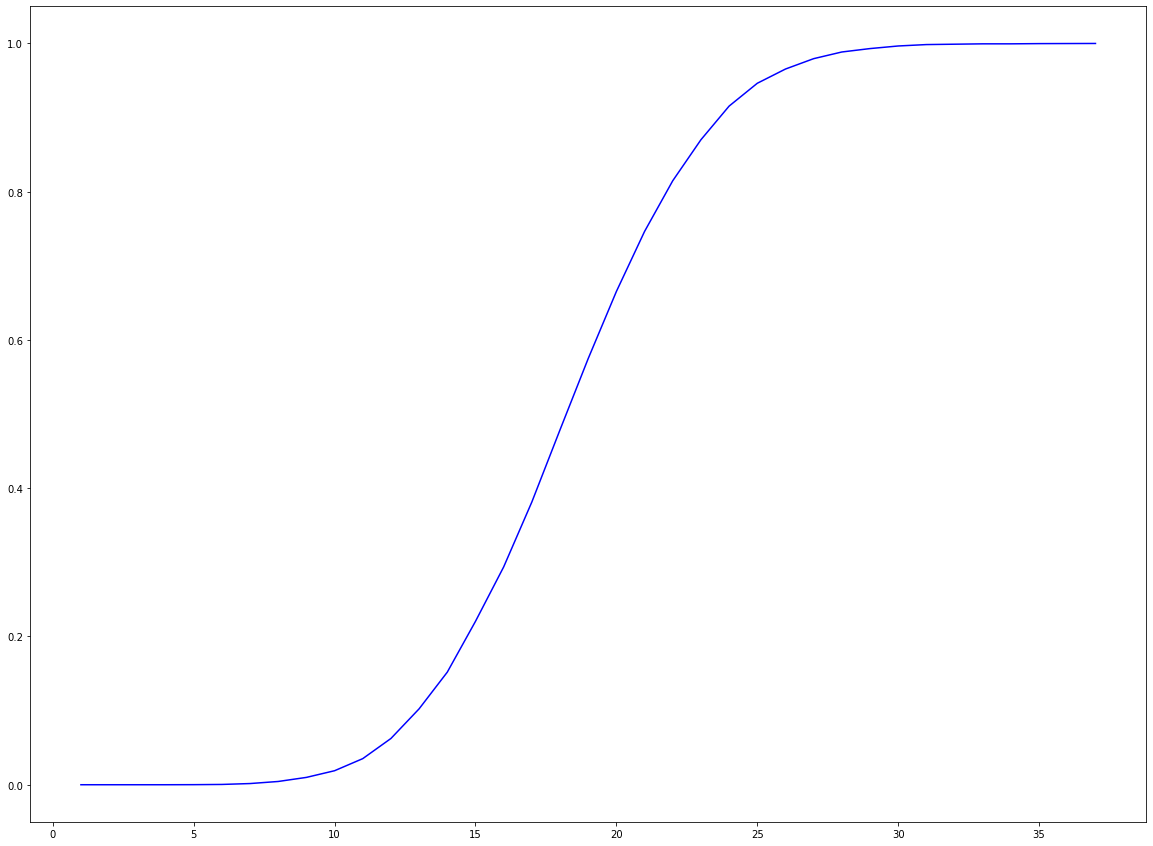

In [225]:
x=[]
y=[]
i = 1
prob = 0
while prob < 1:
    prob = len(sorted[sorted[0] <= i])/n_exp
    x.append(i)
    y.append(prob)
    i+=1
    

plt.figure(figsize=(20, 15))
plt.plot(x, y, color ='blue')